## Análisis de datos - Clase 2

## Introducción al EDA: medidas estadísticas descriptivas 
<hr style="border:1px solid gray">

In [2]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe


#### Funciones auxiliares (helper functions)



In [7]:
def load_dataset():
    return

In [8]:
# Función para graficar
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')
 

    # Sombreado
    if mvd and shade:
        plt.axvspan(media - std, media + std, alpha=0.1, color='orange', label='±1 Std')
        plt.axvline(media + std, color='orange', linestyle=':', label='+1 Std')
        plt.axvline(media - std, color='orange', linestyle=':', label='-1 Std')
        plt.figtext(0.15, 0.80, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var:   {var:.2f}',   fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std:   {std:.2f}',   fontsize=10, color='orange')

    

    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()
    
    return

In [9]:
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

In [10]:
def print_categorias(dataframe, columna):
    print(f"Cantidad de categorías que tiene la variable '{columna}': {dataframe[columna].nunique()}\n")
    print(f"Nombres de categorías presentes en la variable '{columna}': {dataframe[columna].unique()}\n")
    
    freq = dataframe[columna].value_counts()
    freq_rel = dataframe[columna].value_counts(normalize=True).mul(100).round(2)
    
    freq_tabla = pd.DataFrame({'Frecuencia absoluta': freq, 'Frecuencia relativa (%)': freq_rel})
    
    print(f"Frecuencias de cada categoría en la variable '{columna}':\n{freq_tabla}\n")

In [11]:
def plot_pie(data, column, ax=None, startangle=90, palette='pastel', title=None):
    counts = data[column].value_counts()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    
    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=startangle,
        colors=sns.color_palette(palette)
    )
    ax.set_title(title if title else f'Distribución de "{column}"')
    ax.axis('equal') # Asegura que el gráfico sea circular

In [12]:
def plot_frecuencias_relativas(data, column, ax=None, palette='viridis', figsize=(9, 4), title=None):
    total = len(data)
    relative_freq = data[column].value_counts() / total

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(x=relative_freq.values, y=relative_freq.index, hue=relative_freq.index, 
                palette=palette, ax=ax, legend=False)
    
    ax.set_title(title if title else f'Frecuencias relativas de {column}')
    ax.set_xlabel('Frecuencia relativa')
    ax.set_ylabel(column)

plt.show()

In [13]:
def plot_violin_box(data, num_col, cat_col, figsize=(12, 4), palette='pastel', title=None):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    # Violin plot
    sns.violinplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                   palette=palette, ax=axes[0], legend=False)
    axes[0].set_title(f'Violin: {num_col} vs. {cat_col}')
    axes[0].grid(axis='y', ls='--')

    # Box plot
    sns.boxplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                palette=palette, ax=axes[1], legend=False)
    axes[1].set_title(f'Boxplot: {num_col} vs. {cat_col}')
    axes[1].grid(axis='y', ls='--')

    plt.suptitle(title if title else f'{num_col} vs {cat_col}', fontsize=13)
    plt.tight_layout()
    plt.show()


#### Descripción del dataset Recorridos Ecobicis


| Variable      | Descripción                                                                      |
| ------------- | ---------------------------------------------------------------------------------- |
| `id_recorrido`| id del recorrido                                                  |
| `duracion_recorrido` | Duración del recorrido en segundos                                                      |
| `fecha_origen_recorrido`  | Fecha de origen (timestamp)                                               |
| `id_estacion_origen`      | id estacion de origen                                                        |
| `nombre_estacion_origen`  | Nombre estacion de origen                                              |
| `direccion_estacion_origen`       | Direccion estacion de origen                                                   |
| `long_estacion_origen`        | Longitud ubicacion estacion de origen                                                        |
| `lat_estacion_origen`    | Longuitud estacion de origen          |
| `fecha_destino_recorrido`       | Fecha de origen (timestamp) |
| `id_estacion_destino`         | Id estacion destino  |
| `nombre_estacion_destino`  | Nombre estacion destino                                                    |
| `direccion_estacion_destino`        | Direccion estacion de destino                             |
| `long_estacion_destino` | longitud destino                                               |
| `lat_estacion_destino`       | latitud destino                                                  |
| `id_usuario`       | id de usuario                          |
| `modelo_bicicleta`       | Modelo de bicicleta                          |
| `genero` | Genero del usuario (MALE, FEMALE, OTHER)

#### Importamos el dataset
---


In [3]:
# Cargamos el dataset de Titanic
df = pd.read_csv('dataset/trips_2023.csv', thousands=',') # sns.load_dataset Devuelve un Pandas DF

#### Primera inspección
<hr style="border:1px solid gray">

#### a. Recorridos ecobicis
---

In [15]:
print(f"Dimensiones del dataset original: {df.shape}")

# Drop first column
df = df.drop(columns=['Unnamed: 0'])
df.head()

Dimensiones del dataset original: (2622331, 18)


,Id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,género
0,17910696BAEcobici,1848,2023-04-24 10:30:10,358BAEcobici,249 - Balbín,2519 Conesa,-58.465586,-34.561486,2023-04-24 11:00:58,278BAEcobici,233 - MONROE,2519 Superi,-58.469813,-34.564122,861866BAEcobici,ICONIC,MALE
1,17600256BAEcobici,288,2023-03-22 17:40:55,444BAEcobici,061 - Ministerio de Economia,"Balcarce e Yrigoyen, Hipolito Av.",-58.370716,-34.608936,2023-03-22 17:45:43,3BAEcobici,003 - ADUANA,Moreno & Azopardo,-58.368174,-34.611102,217525BAEcobici,ICONIC,FEMALE
2,17255670BAEcobici,1103,2023-02-15 23:12:22,280BAEcobici,222 - SIMON BOLIVAR,"1701 Fernandez Moreno, Baldomero",-58.449379,-34.633528,2023-02-15 23:30:45,280BAEcobici,222 - SIMON BOLIVAR,"1701 Fernandez Moreno, Baldomero",-58.449379,-34.633528,954201BAEcobici,ICONIC,MALE
3,17996972BAEcobici,1165,2023-05-03 11:00:20,273BAEcobici,223 - GAINZA,"494 Gainza, Martin De, Gral.",-58.446751,-34.616758,2023-05-03 11:19:45,367BAEcobici,287 - Belaustegui,"Belaustegui, Luis, Dr. 2890",-58.477209,-34.616212,179414BAEcobici,ICONIC,MALE
4,17148836BAEcobici,378,2023-02-06 06:50:58,65BAEcobici,065 - Julián Álvarez,3822 Guemes,-58.415787,-34.587312,2023-02-06 06:57:16,14BAEcobici,014 - Pacifico,"Santa Fe Av. & Bullrich, Int. Av.",-58.426387,-34.577424,8098BAEcobici,ICONIC,MALE


In [16]:
# rename duracion_recorrido
df = df.rename(columns={'duracion_recorrido':'duracion_recorrido_seg', 'género':'genero'})


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2622331 entries, 0 to 2622330
Data columns (total 17 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Id_recorrido                str    
 1   duracion_recorrido_seg      int64  
 2   fecha_origen_recorrido      str    
 3   id_estacion_origen          str    
 4   nombre_estacion_origen      str    
 5   direccion_estacion_origen   str    
 6   long_estacion_origen        float64
 7   lat_estacion_origen         float64
 8   fecha_destino_recorrido     str    
 9   id_estacion_destino         str    
 10  nombre_estacion_destino     str    
 11  direccion_estacion_destino  str    
 12  long_estacion_destino       float64
 13  lat_estacion_destino        float64
 14  id_usuario                  str    
 15  modelo_bicicleta            str    
 16  genero                      str    
dtypes: float64(4), int64(1), str(12)
memory usage: 812.4 MB


#### Identificamos y ajustamos los tipos de variables

In [18]:
df = df.astype({
      'Id_recorrido': 'str',
      'duracion_recorrido_seg': 'int64',
      'fecha_origen_recorrido': 'datetime64[ns]',
      'id_estacion_origen': 'str',
      'nombre_estacion_origen': 'str',
      'direccion_estacion_origen': 'str',
      'long_estacion_origen': 'float64',  
      'lat_estacion_origen': 'float64',   
      'fecha_destino_recorrido': 'datetime64[ns]',
      'id_estacion_destino': 'str',
      'nombre_estacion_destino': 'str',
      'direccion_estacion_destino': 'str',
      'long_estacion_destino': 'float64',  
      'lat_estacion_destino': 'float64',   
      'id_usuario': 'str',
      'modelo_bicicleta': 'category',  # limited distinct values
      'genero': 'category'  # limited distinct values (MALE/FEMALE/etc)
  })


---
---
## Estadística descriptiva
---
---

### 1. Exploración de VARIABLES NUMÉRICAS

#### 1.1. Medidas de tendencia central: media, mediana y moda


#### Media

In [19]:
np.mean(df['duracion_recorrido_seg'])/60    # con NumPy

np.float64(23.01022199968908)

In [20]:
mean_recorrido = df['duracion_recorrido_seg'].mean()# con Pandas
print("Duracion media en minutos: ", mean_recorrido/60)

Duracion media en minutos:  23.01022199968908


#### Mediana

In [21]:
np.median(df['duracion_recorrido_seg'])/60 # con NumPy (no funciona con nulos)

np.float64(15.533333333333333)

In [22]:
np.median(df['duracion_recorrido_seg'].dropna())/60 # con NumPy (ignorando nulos)

np.float64(15.533333333333333)

In [23]:
df['duracion_recorrido_seg'].median()    # con Pandas

np.float64(932.0)

#### Moda

#### Moda

In [24]:
df['id_estacion_origen'].mode()     # con Pandas

0    175BAEcobici
Name: id_estacion_origen, dtype: str

In [25]:
df.query('id_estacion_origen == "175BAEcobici"').head(3)

,Id_recorrido,duracion_recorrido_seg,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
35,18349462BAEcobici,1029,2023-06-14 23:54:50,175BAEcobici,147 - Constitución,Avenida Juan de Garay 1050,-58.380707,-34.626851,2023-06-15 00:11:59,83BAEcobici,083 - Paraná,1590 Lavalle,-58.389373,-34.603269,468004BAEcobici,ICONIC,MALE
66,16944587BAEcobici,1176,2023-01-16 19:11:15,175BAEcobici,147 - Constitución,Avenida Juan de Garay 1050,-58.380707,-34.626851,2023-01-16 19:30:51,132BAEcobici,132 - CORRIENTES,Reconquista & Corrientes Av.,-58.372763,-34.603369,1917BAEcobici,ICONIC,FEMALE
131,17155654BAEcobici,2749,2023-02-06 17:34:49,175BAEcobici,147 - Constitución,Avenida Juan de Garay 1050,-58.380707,-34.626851,2023-02-06 18:20:38,449BAEcobici,352 - San Jose de Flores,Av. Rivadavia 6955,-58.463297,-34.628836,29130BAEcobici,ICONIC,FEMALE


# Histogramas

In [26]:
total_recorridos = len(df)
total_unique_users = df['id_usuario'].nunique()
total_unique_stations = df['id_estacion_origen'].nunique()

print(f"Total de recorridos: {total_recorridos:,}")
print(f"Total de usuarios: {total_unique_users:,}")
print(f"Total de estaciones: {total_unique_stations:,}")

Total de recorridos: 2,622,331
Total de usuarios: 212,068
Total de estaciones: 364


### Distribucion por genero

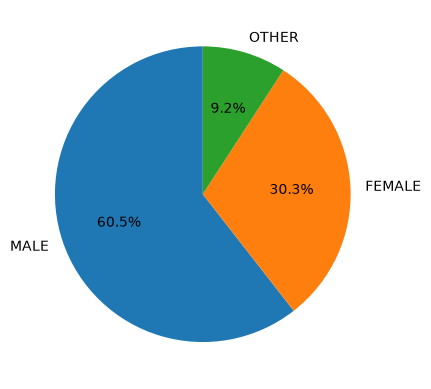

In [32]:
genre_counts = df['genero'].value_counts()
plt.pie(genre_counts, labels=genre_counts.index,autopct='%1.1f%%', startangle=90)

### Duracion recorridos

mean 23.009914842939356
median 16.0
mode 8
skew 207.69187993924396
curtosis 61473.01560807058


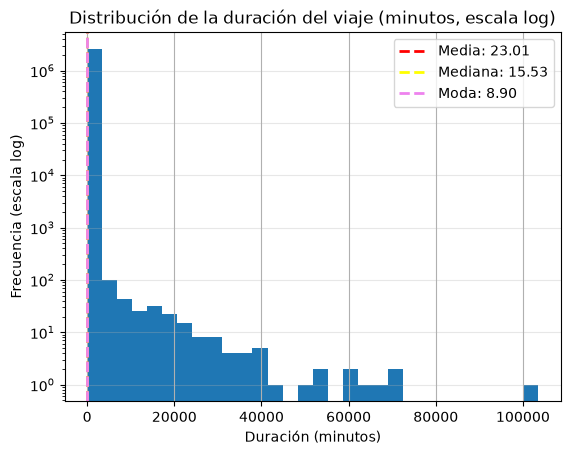

In [162]:
df['duracion_min'] = (df['duracion_recorrido_seg'] / 60).astype(float)

media_duration = df['duracion_min'].mean()
mediana_duration = df['duracion_min'].median()
moda_duration = df['duracion_min'].mode()[0]
skew_duration = df['duracion_min'].skew()
curtosis_duration = df['duracion_min'].kurtosis()

print("mean", mean_duration)
print("median", median_duration)
print("mode", mode_duration)
print("skew", skew_duration)
print("curtosis", curtosis_duration)

df['duracion_min'].hist(bins=30, log=True)
plt.axvline(media_duration, color='red', linestyle='--', linewidth=2, label=f'Media: {media_duration:.2f}')
plt.axvline(mediana_duration, color='yellow', linestyle='--', linewidth=2, label=f'Mediana: {mediana_duration:.2f}')
plt.axvline(mediana_duration, color='violet', linestyle='--', linewidth=2, label=f'Moda: {moda_duration:.2f}')

plt.title('Distribución de la duración del viaje (minutos, escala log)')
plt.xlabel('Duración (minutos)')
plt.ylabel('Frecuencia (escala log)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### Estaciones

Total estaciones:  364
Media: 7204.21
Mediana: 6011.00
Moda: 3692.00


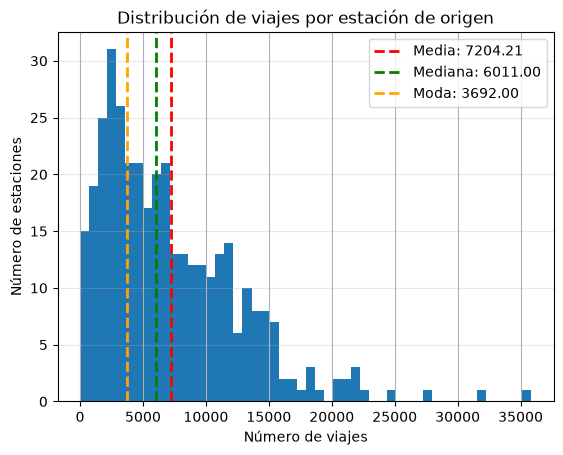

In [163]:
estaciones = df['id_estacion_origen'].value_counts(sort=True)
print("Total estaciones: ", len(estaciones))

mean_val = estaciones.mean()
median_val = estaciones.median()
mode_val = estaciones.mode()[0]

print(f'Media: {mean_val:.2f}')
print(f'Mediana: {median_val:.2f}')
print(f'Moda: {mode_val:.2f}')

estaciones.hist(bins=50)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Mediana: {median_val:.2f}')
plt.axvline(mode_val, color='orange', linestyle='--', linewidth=2, label=f'Moda: {mode_val:.2f}')
plt.title('Distribución de viajes por estación de origen')
plt.xlabel('Número de viajes')
plt.ylabel('Número de estaciones')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [149]:
top_five_estaciones = estaciones.head(5).index

# Get info for those stations
for station_id in top_five_estaciones:
  station_data = df[df['id_estacion_origen'] == station_id].iloc[0]
  trips_count = len(df[df['id_estacion_origen'] == station_id])
  print(f"ID: {station_id}")
  print(f"Nombre: {station_data['nombre_estacion_origen']}")
  print(f"Dirección: {station_data['direccion_estacion_origen']}")
  print(f"Viajes: {trips_count}")
  print("---")


ID: 175BAEcobici
Nombre: 147 - Constitución
Dirección: Avenida Juan de Garay 1050
Viajes: 35834
---
ID: 14BAEcobici
Nombre: 014 - Pacifico
Dirección: Santa Fe Av. & Bullrich, Int. Av.
Viajes: 31698
---
ID: 8BAEcobici
Nombre: 008 - Congreso
Dirección: Cevallos, Virrey& Yrigoyen, Hipolito Av.
Viajes: 27249
---
ID: 5BAEcobici
Nombre: 005 - Plaza Italia
Dirección: Av. Sarmiento 2601
Viajes: 24924
---
ID: 202BAEcobici
Nombre: 001 - FACULTAD DE DERECHO
Dirección: Av. Pres. Figueroa Alcorta 2120
Viajes: 22779
---


In [4]:
print(df.isnull().sum())

Unnamed: 0                        0
Id_recorrido                      0
duracion_recorrido                0
fecha_origen_recorrido            0
id_estacion_origen                0
nombre_estacion_origen            0
direccion_estacion_origen         0
long_estacion_origen              0
lat_estacion_origen               0
fecha_destino_recorrido           0
id_estacion_destino               2
nombre_estacion_destino           2
direccion_estacion_destino        2
long_estacion_destino             2
lat_estacion_destino              2
id_usuario                        0
modelo_bicicleta                  0
género                        11966
dtype: int64
